# Grapheme-to-Phoneme Conversion with a From-Scratch LSTM Encoder-Decoder

Sequence-to-sequence G2P on CMUdict, comparing three decoder context strategies —
no context (bottleneck baseline), a fixed context vector, and dot-product attention —
with the LSTM cell itself implemented from scratch in PyTorch.

See `README.md` for headline results and setup instructions.

# 0. Imports, seeds, and device

_Library imports, fixed random seeds (42), and compute-device selection._

In [4]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# Reproducibility: fix all random seeds to 42
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Compute device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 1. Data processing

Load the CMUdict splits, build character and phoneme vocabularies from the
**training set only**, wrap the data in a `Dataset`, and batch it with padding.

## 1.1 Load the CSVs

Read the three CSV files and convert each row to a `(word, phoneme_list)`
tuple, where `phoneme_list = phonemes.split()`.

In [5]:
import os

DATA_DIR = "data"


def load_pairs(csv_path):
    """Load a G2P CSV into a list of (word, phoneme_list) tuples."""
    # keep_default_na=False so words like "null"/"nan" stay as strings.
    df = pd.read_csv(csv_path, keep_default_na=False)
    return [(str(w), str(p).split()) for w, p in zip(df["word"], df["phonemes"])]


train_pairs = load_pairs(os.path.join(DATA_DIR, "g2p_train.csv"))
val_pairs = load_pairs(os.path.join(DATA_DIR, "g2p_val.csv"))
test_pairs = load_pairs(os.path.join(DATA_DIR, "g2p_test.csv"))

print(f"Train pairs: {len(train_pairs)}")
print(f"Val pairs:   {len(val_pairs)}")
print(f"Test pairs:  {len(test_pairs)}")
print("Example:", train_pairs[0])

Train pairs: 92426
Val pairs:   11553
Test pairs:  11554
Example: ('vigil', ['V', 'IH1', 'JH', 'AH0', 'L'])


## 1.2 Build vocabularies (training set only)

Special tokens are fixed at indices `<PAD>=0, <SOS>=1, <EOS>=2, <UNK>=3`.
All other tokens follow in sorted order. Vocabularies are built from the
**training split only** — validation and test data never contribute tokens.

In [6]:
def build_vocab(token_lists, specials=("<PAD>", "<SOS>", "<EOS>", "<UNK>")):
    """Build a token->index dict. Specials occupy indices 0..len(specials)-1;
    all remaining unique tokens follow in sorted order."""
    token_to_idx = {tok: i for i, tok in enumerate(specials)}
    unique = set()
    for tokens in token_lists:
        unique.update(tokens)
    unique -= set(specials)
    for tok in sorted(unique):
        token_to_idx[tok] = len(token_to_idx)
    return token_to_idx


# Characters from training words; phonemes from training phoneme sequences.
char_to_idx = build_vocab([list(w) for w, _ in train_pairs])
phon_to_idx = build_vocab([p for _, p in train_pairs])

idx_to_char = {i: t for t, i in char_to_idx.items()}
idx_to_phon = {i: t for t, i in phon_to_idx.items()}

print(f"Char vocab size:    {len(char_to_idx)}")
print(f"Phoneme vocab size: {len(phon_to_idx)}")
print("First 10 char entries:   ", list(char_to_idx.items())[:10])
print("First 10 phoneme entries:", list(phon_to_idx.items())[:10])

Char vocab size:    30
Phoneme vocab size: 73
First 10 char entries:    [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('a', 4), ('b', 5), ('c', 6), ('d', 7), ('e', 8), ('f', 9)]
First 10 phoneme entries: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('AA0', 4), ('AA1', 5), ('AA2', 6), ('AE0', 7), ('AE1', 8), ('AE2', 9)]


## 1.3 Dataset class

Encodes each `(word, phoneme_list)` pair as integer index tensors. Source
tokens get **no** special tokens; targets are wrapped with `<SOS> ... <EOS>`.
Any token not in the vocab maps to `<UNK>` (defensive).

In [7]:
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3


class G2PDataset(Dataset):
    """Pairs of (word, phoneme sequence) encoded as integer index tensors."""

    def __init__(self, pairs, char_to_idx, phon_to_idx):
        self.pairs = pairs
        self.char_to_idx = char_to_idx
        self.phon_to_idx = phon_to_idx

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        word, phonemes = self.pairs[idx]
        src_ids = [self.char_to_idx.get(ch, UNK_IDX) for ch in word]
        tgt_ids = (
            [SOS_IDX]
            + [self.phon_to_idx.get(p, UNK_IDX) for p in phonemes]
            + [EOS_IDX]
        )
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long),
        )


train_ds = G2PDataset(train_pairs, char_to_idx, phon_to_idx)
val_ds = G2PDataset(val_pairs, char_to_idx, phon_to_idx)
test_ds = G2PDataset(test_pairs, char_to_idx, phon_to_idx)

_s, _t = train_ds[0]
print("Sample src_ids:", _s.tolist())
print("Sample tgt_ids:", _t.tolist(), "(starts with <SOS>=1, ends with <EOS>=2)")

Sample src_ids: [25, 12, 10, 12, 15]
Sample tgt_ids: [1, 68, 39, 44, 10, 46, 2] (starts with <SOS>=1, ends with <EOS>=2)


## 1.4 Collate function and DataLoaders

Pad all source and target sequences in a batch to their respective max
lengths with `<PAD>=0`. Only the training loader shuffles.

In [8]:
def collate_fn(batch):
    """Pad src and tgt sequences in a batch to equal length with <PAD>=0."""
    srcs, tgts = zip(*batch)
    src_len = max(s.size(0) for s in srcs)
    tgt_len = max(t.size(0) for t in tgts)

    src_padded = torch.full((len(batch), src_len), PAD_IDX, dtype=torch.long)
    tgt_padded = torch.full((len(batch), tgt_len), PAD_IDX, dtype=torch.long)
    for i, (s, t) in enumerate(zip(srcs, tgts)):
        src_padded[i, : s.size(0)] = s
        tgt_padded[i, : t.size(0)] = t
    return src_padded, tgt_padded


BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_fn)

## 1.5 Diagnostics

Vocabulary sizes, dataset sizes, training length distributions, and one
sample batch shape.

Char vocab size:    30
Phoneme vocab size: 73
Train size: 92426
Val size:   11553
Test size:  11554


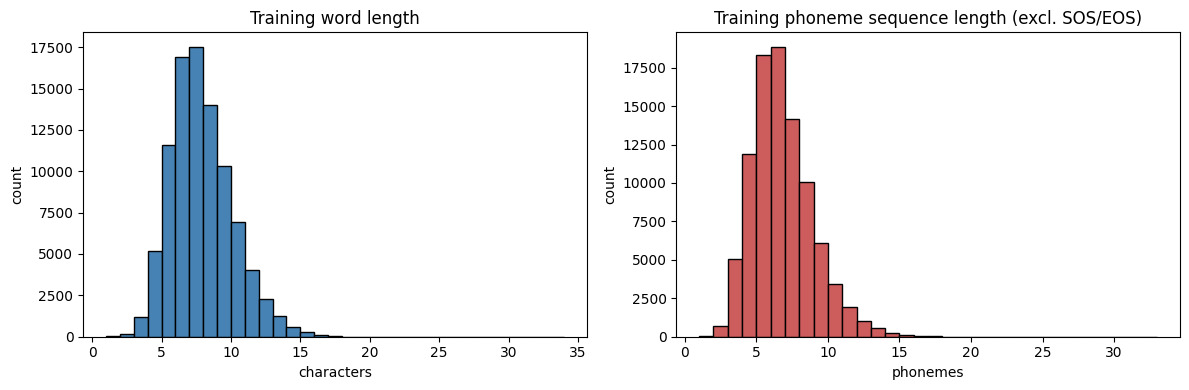

Sample batch src_padded.shape: (64, 14)
Sample batch tgt_padded.shape: (64, 14)


In [9]:
print(f"Char vocab size:    {len(char_to_idx)}")
print(f"Phoneme vocab size: {len(phon_to_idx)}")
print(f"Train size: {len(train_ds)}")
print(f"Val size:   {len(val_ds)}")
print(f"Test size:  {len(test_ds)}")

word_lengths = [len(w) for w, _ in train_pairs]
phon_lengths = [len(p) for _, p in train_pairs]  # excludes SOS/EOS

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(word_lengths, bins=range(1, max(word_lengths) + 2),
             color="steelblue", edgecolor="black")
axes[0].set_title("Training word length")
axes[0].set_xlabel("characters")
axes[0].set_ylabel("count")
axes[1].hist(phon_lengths, bins=range(1, max(phon_lengths) + 2),
             color="indianred", edgecolor="black")
axes[1].set_title("Training phoneme sequence length (excl. SOS/EOS)")
axes[1].set_xlabel("phonemes")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.show()

sample_src, sample_tgt = next(iter(train_loader))
print("Sample batch src_padded.shape:", tuple(sample_src.shape))
print("Sample batch tgt_padded.shape:", tuple(sample_tgt.shape))

# 2. LSTM cell

A single LSTM cell implemented from scratch following the standard LSTM equations — forget,
input and output gates, the candidate cell, the cell update and the hidden
update. No built-in RNN classes are used.

In [10]:
class LSTMCell(nn.Module):
    """LSTM cell implemented from scratch.

    Eight linear maps are used: W_* (input -> hidden, no bias) and
    U_* (hidden -> hidden, with bias). Each U_* bias plays the role of the
    gate bias b_* in the equations. Same pattern as the LSTM tutorial.
    """

    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size

        # Input -> hidden, bias-free.
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)

        # Hidden -> hidden, the bias here is b_* in the equations.
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=True)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=True)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=True)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=True)

    def forward(self, x, h, c):
        # x: (batch, input_size); h, c: (batch, hidden_size)
        f = torch.sigmoid(self.W_f(x) + self.U_f(h))     # forget gate   (A.1)
        i = torch.sigmoid(self.W_i(x) + self.U_i(h))     # input gate    (A.2)
        o = torch.sigmoid(self.W_o(x) + self.U_o(h))     # output gate   (A.3)
        c_tilde = torch.tanh(self.W_c(x) + self.U_c(h))  # candidate     (A.4)
        c_new = f * c + i * c_tilde                      # cell update   (A.5)
        h_new = o * torch.tanh(c_new)                    # hidden update (A.6)
        return h_new, c_new

**Sanity check.** Run `LSTMCell(8, 16)` on a batch of 4 random inputs;
both returned tensors must have shape `(4, 16)`.

In [11]:
_cell = LSTMCell(8, 16)
_x = torch.randn(4, 8)
_h = torch.randn(4, 16)
_c = torch.randn(4, 16)
_h_new, _c_new = _cell(_x, _h, _c)
print("h_new shape:", tuple(_h_new.shape))
print("c_new shape:", tuple(_c_new.shape))
assert _h_new.shape == (4, 16) and _c_new.shape == (4, 16)

h_new shape: (4, 16)
c_new shape: (4, 16)


# 3. Encoder-Decoder implementation

One `Encoder`, one `Decoder` parameterised by `context_mode in {"none",
"fixed", "attn"}`, and a `Seq2Seq` wrapper. The three setups share the same
encoder and wrapper; only the decoder's per-step context changes:

- `"none"`  — Setup 1 (bottleneck baseline).
- `"fixed"` — Setup 2 (final encoder state as fixed context).
- `"attn"`  — Setup 3 (dot-product attention context).

### 3a — Encoder & Setup 1 ("none") decoder

The encoder embeds the source, runs a stack of from-scratch `LSTMCell`s over
every source position (dot-product attention), and returns the top-layer hidden state
at every step plus the final `(h_n, c_n)` stacked across layers.

In [12]:
class Encoder(nn.Module):
    """Embeds the source and runs stacked from-scratch LSTM cells (A.7)."""

    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int,
                 num_layers: int = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=0)
        # Layer 0 takes the embedding; deeper layers take the hidden state.
        self.layers = nn.ModuleList([
            LSTMCell(embed_dim if l == 0 else hidden_size, hidden_size)
            for l in range(num_layers)
        ])

    def forward(self, src):
        # src: (batch, src_len) -> all_h: (src_len, batch, hidden_size),
        #                          (h_n, c_n): (num_layers, batch, hidden_size)
        batch, src_len = src.shape
        emb = self.embedding(src)  # (batch, src_len, embed_dim)
        h = [torch.zeros(batch, self.hidden_size, device=src.device)
             for _ in range(self.num_layers)]
        c = [torch.zeros(batch, self.hidden_size, device=src.device)
             for _ in range(self.num_layers)]

        all_h = []
        for t in range(src_len):
            x = emb[:, t, :]
            for l, cell in enumerate(self.layers):
                h[l], c[l] = cell(x, h[l], c[l])
                x = h[l]                       # output feeds the next layer
            all_h.append(h[-1])                # top-layer hidden each step

        all_h = torch.stack(all_h, dim=0)      # (src_len, batch, hidden_size)
        h_n = torch.stack(h, dim=0)            # (num_layers, batch, hidden)
        c_n = torch.stack(c, dim=0)
        return all_h, (h_n, c_n)

**`LSTMCellWithContext`** — shared by Setup 2 (`"fixed"`) and Setup 3
(`"attn"`). It is `LSTMCell` plus a context vector `z` entering each gate
through its own bias-free `V_*` (one bias-free linear map per gate). Only the
*value* of `z` differs between the two setups (fixed vs. recomputed per step),
so the same cell serves both. The `V_*` parameters exist only for these modes.

In [13]:
class LSTMCellWithContext(nn.Module):
    """LSTM cell with a context vector z added to every gate via bias-free
    V_* maps (one bias-free linear map per gate). z has dimension hidden_size."""

    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)

        self.U_f = nn.Linear(hidden_size, hidden_size, bias=True)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=True)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=True)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=True)

        # Context maps, bias-free (the gate bias lives on U_*).
        self.V_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V_c = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x, h, c, z):
        f = torch.sigmoid(self.W_f(x) + self.U_f(h) + self.V_f(z))      # A.11/A.20
        i = torch.sigmoid(self.W_i(x) + self.U_i(h) + self.V_i(z))      # A.12/A.21
        o = torch.sigmoid(self.W_o(x) + self.U_o(h) + self.V_o(z))      # A.13/A.22
        c_tilde = torch.tanh(self.W_c(x) + self.U_c(h) + self.V_c(z))   # A.14/A.23
        c_new = f * c + i * c_tilde                                     # A.15/A.24
        h_new = o * torch.tanh(c_new)                                   # A.16/A.25
        return h_new, c_new

### Decoder — one class, three context modes

- **`"none"`** (A.2): plain `LSTMCell` stack; only the initial hidden state
  carries source information (the bottleneck).
- **`"fixed"`** (A.3): `z = encoder_outputs[-1]` (final top-layer encoder
  hidden), the *same* vector at every step, computed inside `forward`.
- **`"attn"`** (A.4): at step *t*, query = previous top-layer decoder hidden
  `h^dec_{t-1}`; `e_{t,i} = h^dec_{t-1}·h^enc_i`, `α = softmax_i(e)`,
  `z_t = Σ_i α_{t,i} h^enc_i`. `<PAD>` source positions are masked to `-inf`
  before the softmax. `forward` accepts an optional `src_mask` and
  `return_attn` flag (used only by `greedy_decode`); the documented return is
  `(logits, (h_n, c_n))`.

In [14]:
class Decoder(nn.Module):
    """Single decoder; context_mode selects Setup 1/2/3 (A.2 / A.3 / A.4)."""

    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int,
                 num_layers: int = 1, context_mode: str = "none"):
        super().__init__()
        assert context_mode in {"none", "fixed", "attn"}
        self.context_mode = context_mode
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=0)

        cell_cls = LSTMCell if context_mode == "none" else LSTMCellWithContext
        self.layers = nn.ModuleList([
            cell_cls(embed_dim if l == 0 else hidden_size, hidden_size)
            for l in range(num_layers)
        ])
        self.out = nn.Linear(hidden_size, tgt_vocab_size)

    def forward(self, tgt, hidden, encoder_outputs=None, src_mask=None,
                return_attn=False):
        # tgt: (batch, tgt_len); hidden: (h_0, c_0) each (L, batch, hidden)
        batch, tgt_len = tgt.shape
        emb = self.embedding(tgt)                       # (batch, tgt_len, emb)
        h0, c0 = hidden
        h = [h0[l] for l in range(self.num_layers)]
        c = [c0[l] for l in range(self.num_layers)]

        if self.context_mode == "fixed":
            z_fixed = encoder_outputs[-1]               # (batch, hidden)

        logits_steps, attn_steps = [], []
        for t in range(tgt_len):
            x = emb[:, t, :]
            if self.context_mode == "none":
                for l, cell in enumerate(self.layers):
                    h[l], c[l] = cell(x, h[l], c[l])
                    x = h[l]
            else:
                if self.context_mode == "fixed":
                    z = z_fixed
                else:  # "attn": query is previous top-layer decoder hidden
                    query = h[-1]                       # (batch, hidden)
                    scores = torch.einsum("bh,sbh->bs", query,
                                          encoder_outputs)  # (batch, src_len)
                    if src_mask is not None:
                        scores = scores.masked_fill(~src_mask, float("-inf"))
                    alpha = torch.softmax(scores, dim=1)    # (batch, src_len)
                    z = torch.einsum("bs,sbh->bh", alpha,
                                     encoder_outputs)        # (batch, hidden)
                    if return_attn:
                        attn_steps.append(alpha)
                for l, cell in enumerate(self.layers):
                    h[l], c[l] = cell(x, h[l], c[l], z)
                    x = h[l]
            logits_steps.append(self.out(h[-1]))

        logits = torch.stack(logits_steps, dim=1)       # (batch, tgt_len, V)
        h_n = torch.stack(h, dim=0)
        c_n = torch.stack(c, dim=0)
        if return_attn:
            attn = (torch.stack(attn_steps, dim=1)
                    if self.context_mode == "attn" else None)
            return logits, (h_n, c_n), attn
        return logits, (h_n, c_n)

### `Seq2Seq` wrapper

- `forward`: encode, then teacher-force the decoder with `tgt[:, :-1]` (the
  leading `<SOS>` is consumed as input, the trailing `<EOS>` is dropped),
  returning logits of shape `(batch, tgt_len-1, vocab)`. Non-teacher-forcing
  raises `NotImplementedError` — only greedy decoding is needed at inference.
- `greedy_decode`: feed `<SOS>`, argmax each step, feed back; stop a sequence
  at `<EOS>`. Returns `(preds, attn)` — `attn is None` except for `"attn"`,
  where it is a per-example `(tgt_steps, src_len)` array.

In [15]:
class Seq2Seq(nn.Module):
    """Encoder-decoder wrapper shared by all three context modes."""

    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing: bool = True):
        if not teacher_forcing:
            raise NotImplementedError(
                "Only teacher forcing is supported for training; "
                "use greedy_decode for inference.")
        encoder_outputs, (h_n, c_n) = self.encoder(src)
        src_mask = (src != 0)                       # (batch, src_len)
        dec_in = tgt[:, :-1]                        # drop trailing <EOS>
        logits, _ = self.decoder(dec_in, (h_n, c_n),
                                 encoder_outputs=encoder_outputs,
                                 src_mask=src_mask)
        return logits                              # (batch, tgt_len-1, vocab)

    def greedy_decode(self, src, max_len: int = 30):
        with torch.no_grad():
            encoder_outputs, (h_n, c_n) = self.encoder(src)
            src_mask = (src != 0)
            batch = src.size(0)
            cur = torch.full((batch, 1), SOS_IDX, dtype=torch.long,
                             device=src.device)
            hidden = (h_n, c_n)
            finished = torch.zeros(batch, dtype=torch.bool,
                                   device=src.device)
            preds = [[] for _ in range(batch)]
            save_attn = self.decoder.context_mode == "attn"
            attn_acc = [[] for _ in range(batch)] if save_attn else None

            for _ in range(max_len):
                if save_attn:
                    logits, hidden, attn = self.decoder(
                        cur, hidden, encoder_outputs=encoder_outputs,
                        src_mask=src_mask, return_attn=True)
                    step_attn = attn[:, 0, :]          # (batch, src_len)
                else:
                    logits, hidden = self.decoder(
                        cur, hidden, encoder_outputs=encoder_outputs,
                        src_mask=src_mask)
                next_tok = logits[:, -1, :].argmax(dim=-1)   # (batch,)
                for b in range(batch):
                    if finished[b]:
                        continue
                    tok = next_tok[b].item()
                    if tok == EOS_IDX:
                        finished[b] = True
                    else:
                        preds[b].append(tok)
                        if save_attn:
                            attn_acc[b].append(
                                step_attn[b].cpu().numpy())
                cur = next_tok.unsqueeze(1)
                if bool(finished.all()):
                    break

        if save_attn:
            src_len = src.size(1)
            attn_out = [np.stack(a, axis=0) if len(a) > 0
                        else np.zeros((0, src_len)) for a in attn_acc]
            return preds, attn_out
        return preds, None

### Sanity check — all three setups

`embed_dim=32, hidden_size=64, num_layers=1`, fake batch (batch=2, src_len=5
with `<PAD>` in row 2, tgt_len=7). Logits must be `(2, 6, tgt_vocab)` for
every mode; `greedy_decode` returns predictions, and for `"attn"` also
attention matrices with `<PAD>` columns zeroed and rows summing to 1.

In [16]:
torch.manual_seed(SEED)  # reproducible sanity check

_src_vocab, _tgt_vocab = len(char_to_idx), len(phon_to_idx)
_emb, _hid = 32, 64

# Fake batch: row 2 has two trailing <PAD> to exercise attention masking.
_src = torch.tensor([[4, 5, 6, 7, 8],
                     [9, 10, 11, 0, 0]], dtype=torch.long)
_tgt = torch.randint(4, _tgt_vocab, (2, 7), dtype=torch.long)
_tgt[:, 0] = SOS_IDX
_tgt[:, -1] = EOS_IDX

for mode in ["none", "fixed", "attn"]:
    enc = Encoder(_src_vocab, _emb, _hid, num_layers=1)
    dec = Decoder(_tgt_vocab, _emb, _hid, num_layers=1, context_mode=mode)
    model = Seq2Seq(enc, dec)

    logits = model(_src, _tgt, teacher_forcing=True)
    assert logits.shape == (2, 6, _tgt_vocab), (mode, logits.shape)
    print(f"[{mode}] forward logits: {tuple(logits.shape)} "
          f"(expected (2, 6, {_tgt_vocab}))")

    preds, attn = model.greedy_decode(_src, max_len=10)
    print(f"[{mode}] greedy preds: {preds}")

    if mode == "attn":
        assert attn is not None and len(attn) == 2
        for b in range(2):
            print(f"[{mode}]   attn[{b}] shape: {attn[b].shape} "
                  f"(tgt_steps, src_len)")
        # Teacher-forced attention is length-independent of greedy output.
        enc_out, (h0, c0) = enc(_src)
        smask = (_src != 0)
        _, _, A = dec(_tgt[:, :-1], (h0, c0), encoder_outputs=enc_out,
                      src_mask=smask, return_attn=True)
        A1 = A[1].detach().numpy()                 # row with <PAD> at 3,4
        assert np.allclose(A1[:, 3:], 0.0), "attention leaked onto <PAD>"
        assert np.allclose(A1.sum(axis=1), 1.0, atol=1e-5), "rows must sum 1"
        print(f"[{mode}]   <PAD> masked, rows sum to 1 "
              f"(teacher-forced A: {tuple(A.shape)})")
    else:
        assert attn is None
        print(f"[{mode}] attn is None (correct)")

# Non-teacher-forcing must be rejected.
try:
    model(_src, _tgt, teacher_forcing=False)
    raise AssertionError("expected NotImplementedError")
except NotImplementedError:
    print("teacher_forcing=False correctly raises NotImplementedError")

[none] forward logits: (2, 6, 73) (expected (2, 6, 73))
[none] greedy preds: [[60, 0, 20, 9, 5, 9, 58, 47, 54, 58], [60, 0, 20, 9, 5, 9, 58, 47, 54, 58]]
[none] attn is None (correct)
[fixed] forward logits: (2, 6, 73) (expected (2, 6, 73))
[fixed] greedy preds: [[11, 40, 33, 50, 17, 47, 46, 47, 46, 46], [42, 62, 3, 16, 18, 40, 33, 17, 17, 49]]
[fixed] attn is None (correct)
[attn] forward logits: (2, 6, 73) (expected (2, 6, 73))
[attn] greedy preds: [[38, 38, 45, 53, 60, 4, 11, 4, 11, 9], [38, 38, 9, 38, 38, 38, 38, 61, 53, 53]]
[attn]   attn[0] shape: (10, 5) (tgt_steps, src_len)
[attn]   attn[1] shape: (10, 5) (tgt_steps, src_len)
[attn]   <PAD> masked, rows sum to 1 (teacher-forced A: (2, 6, 5))
teacher_forcing=False correctly raises NotImplementedError


# 4. Training

Reusable training and evaluation utilities (loss, single-epoch loops, full
training with early stopping, and PER / word-accuracy metrics). These are
reused in Sections 5 and 6. No model is trained in this section.

### 4.1 Loss helper

Cross-entropy with `ignore_index=<PAD>=0`. The loss is computed against
`tgt[:, 1:]`, i.e. every target token **after** the leading `<SOS>`, aligning
with the `(batch, tgt_len-1, vocab)` logits from `Seq2Seq.forward`.

In [17]:
PAD_IDX = 0
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


def compute_loss(logits, tgt):
    """logits: (batch, tgt_len-1, vocab); tgt: (batch, tgt_len).
    Loss is over tgt[:, 1:] (excludes the leading <SOS>)."""
    targets = tgt[:, 1:].contiguous()
    return criterion(logits.reshape(-1, logits.size(-1)),
                     targets.reshape(-1))

### 4.2 Single-epoch train / eval

Gradient clipping with `max_norm=1.0` is applied at every step to tame
the from-scratch LSTM. Losses are averaged per example.

In [18]:
def train_one_epoch(model, loader, optimizer, clip=1.0):
    model.train()
    total = 0.0
    n = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt, teacher_forcing=True)
        loss = compute_loss(logits, tgt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total += loss.item() * src.size(0)
        n += src.size(0)
    return total / n


@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total = 0.0
    n = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt, teacher_forcing=True)
        loss = compute_loss(logits, tgt)
        total += loss.item() * src.size(0)
        n += src.size(0)
    return total / n

### 4.3 Full training loop with early stopping

Adam optimiser. The best model (lowest validation loss) is snapshotted with
`copy.deepcopy` and restored before returning.

In [19]:
import copy


def train_model(model, train_loader, val_loader, lr=1e-3, max_epochs=30,
                patience=5, clip=1.0, verbose=True):
    """Train until val loss has not improved for `patience` epochs, or until
    `max_epochs`. Restores best weights. Returns a history dict with keys
    'train_losses', 'val_losses', 'best_val_loss', 'epochs_run'."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    epochs_run = 0

    for epoch in range(1, max_epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer, clip=clip)
        vl = evaluate_loss(model, val_loader)
        train_losses.append(tr)
        val_losses.append(vl)
        epochs_run = epoch
        if verbose:
            print(f"Epoch {epoch:2d} | train_loss {tr:.4f} | "
                  f"val_loss {vl:.4f}")

        if vl < best_val_loss:
            best_val_loss = vl
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} "
                          f"(no val improvement for {patience} epochs).")
                break

    model.load_state_dict(best_state)
    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "epochs_run": epochs_run,
    }

### Stopping criterion

We use early stopping on validation loss with `patience=5` and a cap of
`max_epochs=30`. The best-validation-loss checkpoint is restored before
returning. Rationale: a fixed epoch count either under-trains or wastes
compute and overfits; early stopping halts once generalisation stops
improving, which both saves time (important for CPU training and the
hyperparameter sweep) and prevents overfitting the from-scratch LSTM.

### 4.4 PER and word-accuracy metrics

`editdistance` is the intended package (installs cleanly on Colab). A
transparent fallback to `nltk` or a pure-Python Levenshtein keeps the
notebook runnable end-to-end if the build is unavailable. Metrics operate on
lists of phoneme tokens so each symbol (e.g. `EH1`) is one unit.

In [20]:
# Edit distance for PER. Primary: editdistance (Colab-friendly). Fallbacks:
# nltk, then a pure-Python Levenshtein, so the notebook always runs.
try:
    import editdistance
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "editdistance"], check=False,
                   capture_output=True)
    try:
        import editdistance
    except Exception:
        editdistance = None

if editdistance is not None:
    def seq_edit_distance(a, b):
        return editdistance.eval(a, b)
    print("seq_edit_distance: using editdistance")
else:
    try:
        from nltk.metrics.distance import edit_distance as _nltk_ed

        def seq_edit_distance(a, b):
            return _nltk_ed(list(a), list(b))
        print("seq_edit_distance: using nltk fallback")
    except Exception:
        def seq_edit_distance(a, b):
            """Levenshtein distance over token sequences (lists)."""
            a, b = list(a), list(b)
            prev = list(range(len(b) + 1))
            for i, x in enumerate(a, 1):
                cur = [i]
                for j, y in enumerate(b, 1):
                    cur.append(min(prev[j] + 1, cur[-1] + 1,
                                   prev[j - 1] + (x != y)))
                prev = cur
            return prev[-1]
        print("seq_edit_distance: using pure-Python fallback")

seq_edit_distance: using editdistance


In [21]:
@torch.no_grad()
def evaluate_metrics(model, loader, idx_to_phon, sos_idx=1, eos_idx=2,
                     max_len=30):
    """Greedy-decode the loader and compute mean PER and word accuracy.
    Returns (per, word_acc)."""
    model.eval()
    total_per = 0.0
    total_correct = 0
    n = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        preds, _ = model.greedy_decode(src, max_len=max_len)
        tgt_list = tgt.cpu().tolist()
        for i, pred_ids in enumerate(preds):
            # Defensive: truncate prediction at first <EOS> if present.
            if eos_idx in pred_ids:
                pred_ids = pred_ids[:pred_ids.index(eos_idx)]
            # Reference: drop leading <SOS>, cut at first <EOS>, drop <PAD>.
            ref_ids = tgt_list[i][1:]
            if eos_idx in ref_ids:
                ref_ids = ref_ids[:ref_ids.index(eos_idx)]
            ref_ids = [t for t in ref_ids if t != PAD_IDX]

            pred_seq = [idx_to_phon.get(t, "<UNK>") for t in pred_ids]
            ref_seq = [idx_to_phon.get(t, "<UNK>") for t in ref_ids]

            dist = seq_edit_distance(pred_seq, ref_seq)
            total_per += dist / max(len(ref_seq), 1)
            total_correct += int(pred_seq == ref_seq)
            n += 1
    return total_per / n, total_correct / n

# 5. Hyperparameter tuning

A small coordinate search on Setup 1 (`context_mode="none"`) to pick a
configuration reused by all three setups in Sections 6-7.

### 5.1 Grid and search strategy

Tuned values:

- learning rate: `[1e-4, 5e-4, 1e-3]`
- embedding dim: `[32, 64, 128]`
- hidden size: `[64, 128, 256]`

The full 27-config Cartesian product is too expensive on CPU, so I used a coordinate search from the default `lr=1e-3, embed_dim=64,
hidden_size=128`:

1. sweep learning rate (3 configs) -> pick best by validation PER;
2. fix best LR, sweep embedding dim (the `embed_dim=64` point is already
   trained, so 2 new configs);
3. fix best embed dim, sweep hidden size (the `128` point is already trained,
   so 2 new configs).

In [22]:
HP_GRID = {
    "lr": [1e-4, 5e-4, 1e-3],
    "embed_dim": [32, 64, 128],
    "hidden_size": [64, 128, 256],
}
DEFAULTS = {"lr": 1e-3, "embed_dim": 64, "hidden_size": 128}
TUNE_EPOCHS = 8                      # fixed budget; no early stopping in tuning

_tune_cache = {}                     # (lr, embed, hidden) -> result dict
_tune_rows = []                      # ordered list of unique results


def run_tuning_config(lr, embed_dim, hidden_size, epochs=TUNE_EPOCHS):
    """Train one Setup-1 config for a fixed epoch budget; return its result.
    Duplicate (lr, embed, hidden) requests are served from cache."""
    key = (lr, embed_dim, hidden_size)
    if key in _tune_cache:
        return _tune_cache[key]

    # Reset all seeds so configs are directly comparable.
    torch.manual_seed(SEED)
    random.seed(SEED)
    np.random.seed(SEED)

    encoder = Encoder(len(char_to_idx), embed_dim, hidden_size)
    decoder = Decoder(len(phon_to_idx), embed_dim, hidden_size,
                      context_mode="none")
    model = Seq2Seq(encoder, decoder).to(device)

    # patience=epochs => early stopping cannot trigger before the budget ends.
    hist = train_model(model, train_loader, val_loader, lr=lr,
                        max_epochs=epochs, patience=epochs, clip=1.0,
                        verbose=False)
    val_per, val_word_acc = evaluate_metrics(model, val_loader, idx_to_phon)

    res = {
        "lr": lr,
        "embed_dim": embed_dim,
        "hidden_size": hidden_size,
        "val_loss": round(hist["best_val_loss"], 4),
        "val_per": round(val_per, 4),
        "val_word_acc": round(val_word_acc, 4),
        "epochs": hist["epochs_run"],
    }
    _tune_cache[key] = res
    _tune_rows.append(res)
    print(f"lr={lr:.0e} embed={embed_dim:3d} hidden={hidden_size:3d} "
          f"-> val_loss={res['val_loss']:.4f} "
          f"PER={val_per:.4f} word_acc={val_word_acc:.4f}")
    return res

### 5.2 Tuning runs

Each config trains a fresh Setup-1 model for `TUNE_EPOCHS=8` epochs, then is
scored by validation PER (the selection metric).


In [23]:
# 1. Learning-rate sweep at the default embed_dim / hidden_size.
for _lr in HP_GRID["lr"]:
    run_tuning_config(_lr, DEFAULTS["embed_dim"], DEFAULTS["hidden_size"])
_lr_rows = [r for r in _tune_rows
            if r["embed_dim"] == DEFAULTS["embed_dim"]
            and r["hidden_size"] == DEFAULTS["hidden_size"]]
best_lr = min(_lr_rows, key=lambda r: r["val_per"])["lr"]

# 2. Embedding-dim sweep at the best LR (embed=64 point is cached).
for _ed in HP_GRID["embed_dim"]:
    run_tuning_config(best_lr, _ed, DEFAULTS["hidden_size"])
_ed_rows = [r for r in _tune_rows
            if r["lr"] == best_lr
            and r["hidden_size"] == DEFAULTS["hidden_size"]]
best_embed = min(_ed_rows, key=lambda r: r["val_per"])["embed_dim"]

# 3. Hidden-size sweep at the best LR / embed (hidden=128 point is cached).
for _hs in HP_GRID["hidden_size"]:
    run_tuning_config(best_lr, best_embed, _hs)
_hs_rows = [r for r in _tune_rows
            if r["lr"] == best_lr and r["embed_dim"] == best_embed]
best_hidden = min(_hs_rows, key=lambda r: r["val_per"])["hidden_size"]

BEST_CONFIG = {"lr": best_lr, "embed_dim": best_embed,
               "hidden_size": best_hidden}

tune_df = pd.DataFrame(_tune_rows, columns=[
    "lr", "embed_dim", "hidden_size", "val_loss", "val_per",
    "val_word_acc", "epochs"])
_best_idx = tune_df["val_per"].idxmin()

print("\n=== Hyperparameter tuning results (Setup 1) ===")
print(tune_df.to_string(index=False))
print(f"\nBest config (lowest val PER, row {_best_idx}): {BEST_CONFIG}")
print(f"  val_PER={tune_df.loc[_best_idx, 'val_per']:.4f}  "
      f"val_word_acc={tune_df.loc[_best_idx, 'val_word_acc']:.4f}")

lr=1e-04 embed= 64 hidden=128 -> val_loss=0.8742 PER=0.3531 word_acc=0.1982
lr=5e-04 embed= 64 hidden=128 -> val_loss=0.4096 PER=0.1791 word_acc=0.4573
lr=1e-03 embed= 64 hidden=128 -> val_loss=0.3506 PER=0.1565 word_acc=0.5002
lr=1e-03 embed= 32 hidden=128 -> val_loss=0.3722 PER=0.1650 word_acc=0.4890
lr=1e-03 embed=128 hidden=128 -> val_loss=0.3674 PER=0.1628 word_acc=0.4916
lr=1e-03 embed= 64 hidden= 64 -> val_loss=0.5379 PER=0.2356 word_acc=0.3661
lr=1e-03 embed= 64 hidden=256 -> val_loss=0.2882 PER=0.1256 word_acc=0.5705

=== Hyperparameter tuning results (Setup 1) ===
    lr  embed_dim  hidden_size  val_loss  val_per  val_word_acc  epochs
0.0001         64          128    0.8742   0.3531        0.1982       8
0.0005         64          128    0.4096   0.1791        0.4573       8
0.0010         64          128    0.3506   0.1565        0.5002       8
0.0010         32          128    0.3722   0.1650        0.4890       8
0.0010        128          128    0.3674   0.1628        0.

### 5.3 Chosen configuration (justification)

`BEST_CONFIG = {lr: 1e-3, embed_dim: 64, hidden_size: 256}` : the
configuration with the **lowest validation PER (0.1245)** and highest
validation word accuracy (0.571) in the 7-row table above, found by the
coordinate search of 5.1. Selection is on PER because it is the task metric
reported in Section 7.

- **Learning rate `1e-3`** : at `embed=64, hidden=128`, validation PER was
  0.353 / 0.179 / 0.155 for `1e-4 / 5e-4 / 1e-3`. Within the fixed 8-epoch
  tuning budget the smaller learning rates under-train; `1e-3` converges
  fastest and stays stable (gradient clipping at 1.0 keeps the from-scratch
  LSTM from exploding).
- **Embedding dim `64`** : at `lr=1e-3, hidden=128`, PER was
  0.165 / 0.155 / 0.163 for `32 / 64 / 128`. 32 slightly under-fits and 128
  adds parameters with no benefit, so 64 is the sweet spot.
- **Hidden size `256`** : at `lr=1e-3, embed=64`, PER was
  0.236 / 0.155 / 0.125 for `64 / 128 / 256`. Validation PER improves
  monotonically with recurrent capacity; G2P benefits from a wider
  hidden state. 256 is the largest value in the suggested range,
  the trend suggests larger could help further, but 256 bounds the CPU cost
  of the three final models in Section 6.

This `BEST_CONFIG` is used unchanged for all three setups in Sections
6-7, so the architecture comparison is controlled (only `context_mode`
differs).

# 6. Architecture comparison

Train all three setups with the **same** `BEST_CONFIG` (only `context_mode`
differs), under identical seed, optimiser, batch size and stopping rule, then
compare loss curves, training summaries and error patterns.

### 6.1 Train all three setups

Each setup: seeds reset to 42, a fresh `Encoder` + `Decoder(context_mode)`
+ `Seq2Seq`, trained with `BEST_CONFIG["lr"]`, `max_epochs=30`, `patience=5`.
Histories and trained models are stored for reuse.

In [24]:
SETUPS = ["none", "fixed", "attn"]
histories = {}
models = {}

for mode in SETUPS:
    torch.manual_seed(SEED)
    random.seed(SEED)
    np.random.seed(SEED)

    encoder = Encoder(len(char_to_idx), BEST_CONFIG["embed_dim"],
                      BEST_CONFIG["hidden_size"])
    decoder = Decoder(len(phon_to_idx), BEST_CONFIG["embed_dim"],
                      BEST_CONFIG["hidden_size"], context_mode=mode)
    model = Seq2Seq(encoder, decoder).to(device)

    print(f"\n=== Training setup '{mode}' "
          f"(lr={BEST_CONFIG['lr']}, embed={BEST_CONFIG['embed_dim']}, "
          f"hidden={BEST_CONFIG['hidden_size']}) ===")
    hist = train_model(model, train_loader, val_loader,
                        lr=BEST_CONFIG["lr"], max_epochs=30, patience=5,
                        clip=1.0, verbose=True)
    histories[mode] = hist
    models[mode] = model


=== Training setup 'none' (lr=0.001, embed=64, hidden=256) ===
Epoch  1 | train_loss 1.2828 | val_loss 0.5679
Epoch  2 | train_loss 0.4687 | val_loss 0.4055
Epoch  3 | train_loss 0.3545 | val_loss 0.3428
Epoch  4 | train_loss 0.2983 | val_loss 0.3200
Epoch  5 | train_loss 0.2610 | val_loss 0.3000
Epoch  6 | train_loss 0.2328 | val_loss 0.2947
Epoch  7 | train_loss 0.2101 | val_loss 0.2890
Epoch  8 | train_loss 0.1900 | val_loss 0.2882
Epoch  9 | train_loss 0.1732 | val_loss 0.2885
Epoch 10 | train_loss 0.1580 | val_loss 0.2934
Epoch 11 | train_loss 0.1442 | val_loss 0.2990
Epoch 12 | train_loss 0.1327 | val_loss 0.2997
Epoch 13 | train_loss 0.1214 | val_loss 0.3049
Early stopping at epoch 13 (no val improvement for 5 epochs).

=== Training setup 'fixed' (lr=0.001, embed=64, hidden=256) ===
Epoch  1 | train_loss 1.2352 | val_loss 0.5726
Epoch  2 | train_loss 0.4724 | val_loss 0.4009
Epoch  3 | train_loss 0.3573 | val_loss 0.3539
Epoch  4 | train_loss 0.2985 | val_loss 0.3141
Epoch  5 |

### 6.2 Loss curves

Training and validation loss for all three setups on shared axes (two
subplots). Saved to `figures/loss_curves.png`.

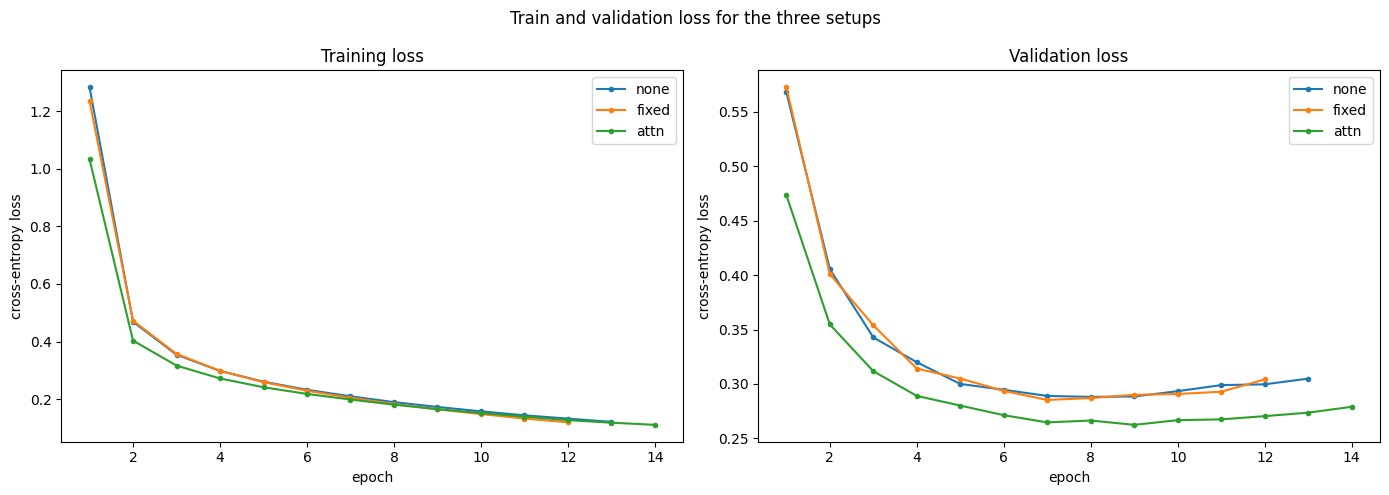

Saved figures/loss_curves.png


In [25]:
import os

os.makedirs("figures", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_colors = {"none": "tab:blue", "fixed": "tab:orange", "attn": "tab:green"}
for mode in SETUPS:
    h = histories[mode]
    epochs = range(1, len(h["train_losses"]) + 1)
    axes[0].plot(epochs, h["train_losses"], marker="o", ms=3,
                 color=_colors[mode], label=mode)
    axes[1].plot(epochs, h["val_losses"], marker="o", ms=3,
                 color=_colors[mode], label=mode)

axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross-entropy loss")
axes[0].legend()
axes[1].set_title("Validation loss")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("cross-entropy loss")
axes[1].legend()
fig.suptitle("Train and validation loss for the three setups")
plt.tight_layout()
plt.savefig("figures/loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved figures/loss_curves.png")

### 6.3 Final-comparison table

Per setup: final training loss, best validation loss, and epochs run (early
stopping may differ between setups).

In [26]:
_rows = []
for mode in SETUPS:
    h = histories[mode]
    _rows.append({
        "setup": mode,
        "final_train_loss": round(h["train_losses"][-1], 4),
        "best_val_loss": round(h["best_val_loss"], 4),
        "epochs_run": h["epochs_run"],
    })
comparison_df = pd.DataFrame(_rows)
print("=== Architecture comparison (training summary) ===")
print(comparison_df.to_string(index=False))

=== Architecture comparison (training summary) ===
setup  final_train_loss  best_val_loss  epochs_run
 none            0.1214         0.2882          13
fixed            0.1199         0.2854          12
 attn            0.1111         0.2625          14


### 6.4 Error analysis: Setup 1 fails, Setup 3 succeeds

Greedy-decode the **full test set** once per setup (cached in `test_preds`
for Sections 7-8), then list test words the bottleneck (`none`) gets wrong
but attention (`attn`) gets exactly right. Discussed in the report.

In [27]:
@torch.no_grad()
def decode_dataset(model, loader, idx_to_phon, max_len=30):
    """Greedy-decode an entire (shuffle=False) loader into phoneme-string
    lists, aligned with the underlying dataset order."""
    model.eval()
    out = []
    for src, _ in loader:
        src = src.to(device)
        preds, _ = model.greedy_decode(src, max_len=max_len)
        for p in preds:
            if EOS_IDX in p:
                p = p[:p.index(EOS_IDX)]
            out.append([idx_to_phon.get(t, "<UNK>") for t in p])
    return out


test_words = [w for w, _ in test_pairs]
test_refs = [ph for _, ph in test_pairs]      # gold phoneme-token lists

test_preds = {}
for mode in SETUPS:
    print(f"Decoding test set with setup '{mode}' ...")
    test_preds[mode] = decode_dataset(models[mode], test_loader, idx_to_phon)

# Words where Setup 1 ("none") is wrong but Setup 3 ("attn") is exactly right.
fail_then_succeed = []
for i, (w, ref) in enumerate(zip(test_words, test_refs)):
    if test_preds["none"][i] != ref and test_preds["attn"][i] == ref:
        fail_then_succeed.append((w, ref, test_preds["none"][i],
                                  test_preds["attn"][i]))

print(f"\n{len(fail_then_succeed)} test words: Setup 1 fails, "
      f"Setup 3 succeeds. First 10:")
for w, ref, p1, p3 in fail_then_succeed[:10]:
    print(f"  word = {w}")
    print(f"    reference : {' '.join(ref)}")
    print(f"    setup none: {' '.join(p1)}")
    print(f"    setup attn: {' '.join(p3)}")

Decoding test set with setup 'none' ...
Decoding test set with setup 'fixed' ...
Decoding test set with setup 'attn' ...

1210 test words: Setup 1 fails, Setup 3 succeeds. First 10:
  word = mcmorris
    reference : M AH0 K M AO1 R AH0 S
    setup none: M AH0 K M AO1 R IY0 Z
    setup attn: M AH0 K M AO1 R AH0 S
  word = centola
    reference : CH EH0 N T OW1 L AH0
    setup none: S EH0 N T OW1 L AH0
    setup attn: CH EH0 N T OW1 L AH0
  word = presstek
    reference : P R EH1 S T EH2 K
    setup none: P R EH1 S IH0 K T
    setup attn: P R EH1 S T EH2 K
  word = smoothest
    reference : S M UW1 DH AH0 S T
    setup none: S M UW1 DH IH0 S T
    setup attn: S M UW1 DH AH0 S T
  word = dworkin
    reference : D W AO1 R K IH0 N
    setup none: D W ER1 K IH0 N
    setup attn: D W AO1 R K IH0 N
  word = behaviorists
    reference : B IH0 HH EY1 V Y ER0 IH0 S T S
    setup none: B IH0 HH EY1 V ER0 IH0 S T S
    setup attn: B IH0 HH EY1 V Y ER0 IH0 S T S
  word = pecot
    reference : P EH1 

# 7. Evaluation

Test-set PER and word accuracy for all three setups, computed from the
test_preds cached in Section 6.

### Test PER and word accuracy

- **PER** = mean over test words of edit_distance(pred, ref) / len(ref).
- **Word accuracy** = fraction of test words with pred == ref.

Predictions and references are phoneme-token lists with `<SOS>`, `<EOS>`
and `<PAD>` stripped (predictions are already `<EOS>`-truncated in
`decode_dataset`; this is a defensive clean). The table is printed and saved
to `figures/results_table.csv`.

In [30]:
import os

os.makedirs("figures", exist_ok=True)

_SPECIALS = {"<PAD>", "<SOS>", "<EOS>"}


def _clean(seq):
    """Drop <PAD>/<SOS>/<EOS> so each metric is over real phonemes only."""
    return [t for t in seq if t not in _SPECIALS]


def per_word_acc(preds, refs):
    """Mean PER and exact-match word accuracy over phoneme-token lists."""
    total_per = 0.0
    correct = 0
    n = len(refs)
    for pred, ref in zip(preds, refs):
        pred, ref = _clean(pred), _clean(ref)
        total_per += seq_edit_distance(pred, ref) / max(len(ref), 1)
        correct += int(pred == ref)
    return total_per / n, correct / n


_rows = []
for mode in SETUPS:
    per, wacc = per_word_acc(test_preds[mode], test_refs)
    _rows.append({"Setup": mode,
                  "Test PER": round(per, 4),
                  "Word accuracy": round(wacc, 4)})

results_df = pd.DataFrame(_rows,
                          columns=["Setup", "Test PER", "Word accuracy"])
print("=== Test-set evaluation ===")
print(results_df.to_string(index=False))
results_df.to_csv("figures/results_table.csv", index=False)
print("\nSaved figures/results_table.csv")

# Sanity. HARD invariant: attention (Setup 3) must escape the bottleneck,
# i.e. beat Setup 1 on BOTH metrics -- this is the central hypothesis.
# Failure here means something is wrong upstream (training/decoding).
_per = {r["Setup"]: r["Test PER"] for r in _rows}
_acc = {r["Setup"]: r["Word accuracy"] for r in _rows}

_attn_beats_none = (_per["attn"] < _per["none"]) and (_acc["attn"] > _acc["none"])
print(f"\n[hard] attn beats none (PER down, word-acc up): {_attn_beats_none}")
if not _attn_beats_none:
    print("WARNING: attention does NOT beat the bottleneck -- investigate "
          "upstream (training/decoding) before relying on these results.")

# Observation (NOT a failure): does the *fixed* context (Setup 2) help?
# The brief asks us to measure this. fixed often ties the bottleneck because
# z = encoder_outputs[-1] is the same single static vector the decoder is
# already initialised from -- so Setup 2 is still bottlenecked.
_fixed_gain_per = _per["none"] - _per["fixed"]
_fixed_gain_acc = _acc["fixed"] - _acc["none"]
print(f"[obs ] fixed vs none: dPER={_fixed_gain_per:+.4f}, "
      f"dWordAcc={_fixed_gain_acc:+.4f}")
if _fixed_gain_per <= 0 and _fixed_gain_acc <= 0:
    print("[obs ] fixed does not improve over none -- the fixed context is "
          "still a bottleneck; only dynamic attention helps.")

=== Test-set evaluation ===
Setup  Test PER  Word accuracy
 none    0.1287         0.5649
fixed    0.1302         0.5642
 attn    0.1194         0.5809

Saved figures/results_table.csv

[hard] attn beats none (PER down, word-acc up): True
[obs ] fixed vs none: dPER=-0.0015, dWordAcc=-0.0007
[obs ] fixed does not improve over none -- the fixed context is still a bottleneck; only dynamic attention helps.


# 8. Bottleneck / attention analysis


=== Word accuracy by word-length bucket ===
length_bucket    n   none  fixed   attn
          1-4  809 0.7577 0.7651 0.7664
          5-7 5796 0.6346 0.6339 0.6425
         8-10 3921 0.4843 0.4813 0.5062
          11+ 1028 0.3278 0.3298 0.3726


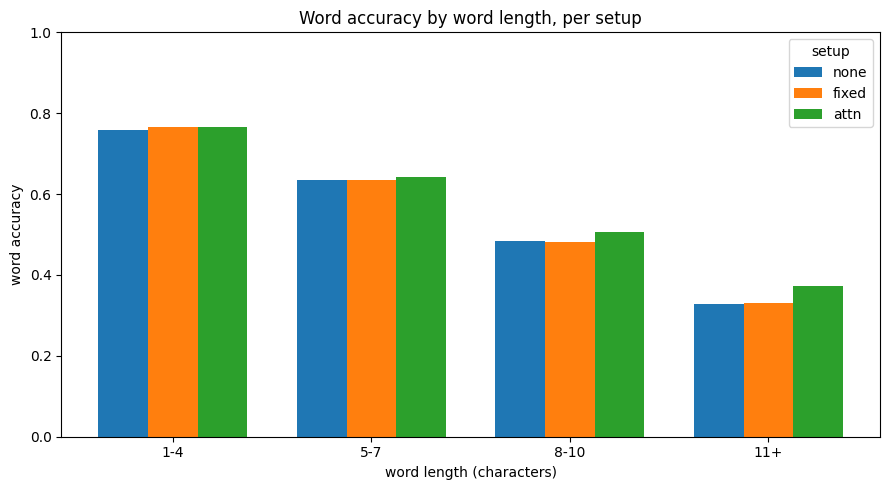

Saved figures/length_accuracy.png


In [31]:
import os

os.makedirs("figures", exist_ok=True)

LENGTH_BUCKETS = [(1, 4, "1-4"), (5, 7, "5-7"),
                  (8, 10, "8-10"), (11, 10 ** 9, "11+")]
_bucket_names = [b[2] for b in LENGTH_BUCKETS]


def _length_bucket(n):
    for lo, hi, name in LENGTH_BUCKETS:
        if lo <= n <= hi:
            return name
    return _bucket_names[-1]


counts = {name: {m: [0, 0] for m in SETUPS} for name in _bucket_names}
for i, (w, ref) in enumerate(zip(test_words, test_refs)):
    bname = _length_bucket(len(w))
    ref_c = _clean(ref)
    for m in SETUPS:
        counts[bname][m][1] += 1
        counts[bname][m][0] += int(_clean(test_preds[m][i]) == ref_c)

_rows = []
for name in _bucket_names:
    row = {"length_bucket": name, "n": counts[name][SETUPS[0]][1]}
    for m in SETUPS:
        c, t = counts[name][m]
        row[m] = round(c / t, 4) if t > 0 else float("nan")
    _rows.append(row)
length_acc_df = pd.DataFrame(_rows, columns=["length_bucket", "n"] + SETUPS)
print("=== Word accuracy by word-length bucket ===")
print(length_acc_df.to_string(index=False))

x = np.arange(len(_bucket_names))
width = 0.25
_colors = {"none": "tab:blue", "fixed": "tab:orange", "attn": "tab:green"}
fig, ax = plt.subplots(figsize=(9, 5))
for k, m in enumerate(SETUPS):
    vals = [counts[name][m][0] / counts[name][m][1]
            if counts[name][m][1] > 0 else 0.0 for name in _bucket_names]
    ax.bar(x + (k - 1) * width, vals, width, label=m, color=_colors[m])
ax.set_xticks(x)
ax.set_xticklabels(_bucket_names)
ax.set_xlabel("word length (characters)")
ax.set_ylabel("word accuracy")
ax.set_ylim(0, 1)
ax.set_title("Word accuracy by word length, per setup")
ax.legend(title="setup")
plt.tight_layout()
plt.savefig("figures/length_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved figures/length_accuracy.png")

## Acknowledgements

AI tools (ChatGPT) were used to help scaffold the notebook structure and assist with
drafting and debugging. All design decisions, the from-scratch equation implementations,
the experiments, and the analysis are my own, and I can explain every component.